In [5]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,root_mean_squared_error,confusion_matrix,roc_auc_score,log_loss
from sklearn.metrics import f1_score,accuracy_score,recall_score,precision_score,classification_report
from tqdm import tqdm
import os
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler,PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
import datetime as dt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import BernoulliNB,GaussianNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.tree import DecisionTreeClassifier,plot_tree,DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier,BaggingRegressor,VotingClassifier,VotingRegressor,RandomForestClassifier,RandomForestRegressor,RandomForestRegressor
from sklearn.metrics import accuracy_score

In [6]:
cancer=pd.read_csv(r"../Datasets/BreastCancer.csv")
cancer

,Code,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses,Class
0,61634,5,4,3,1,2,2,2,3,1,Benign
1,63375,9,1,2,6,4,10,7,7,2,Malignant
2,76389,10,4,7,2,2,8,6,1,1,Malignant
3,95719,6,10,10,10,8,10,7,10,7,Malignant
4,128059,1,1,1,1,2,5,5,1,1,Benign
...,...,...,...,...,...,...,...,...,...,...,...
694,1369821,10,10,10,10,5,10,10,10,7,Malignant
695,1371026,5,10,10,10,4,10,5,6,3,Malignant
696,1371920,5,1,1,1,2,1,3,2,1,Benign
697,8233704,4,1,1,1,1,1,2,1,1,Benign


In [7]:
X = cancer.drop(['Code','Class'],axis=1)
y=cancer['Class']
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3,random_state=26,stratify = cancer['Class'])

In [8]:
features = [2,3,4,5,6,7]
scores = []
for f in tqdm(features) :
    for n in [25,50,75,100,125]:
         rf = RandomForestClassifier(random_state=26,max_features=f,n_estimators=n)
         rf.fit(X_train,y_train)
         y_pred_prob = rf.predict_proba(X_test)
         scores.append([f,n,log_loss(y_test,y_pred_prob)])
df_score = pd.DataFrame(scores,columns = ['max_features','n_estimators','log_loss'])
df_score.sort_values('log_loss',ascending = False)

  0%|                                                                                            | 0/6 [00:00<?, ?it/s]

 17%|██████████████                                                                      | 1/6 [00:00<00:03,  1.43it/s]

 33%|████████████████████████████                                                        | 2/6 [00:01<00:02,  1.39it/s]

 50%|██████████████████████████████████████████                                          | 3/6 [00:02<00:02,  1.39it/s]

 67%|████████████████████████████████████████████████████████                            | 4/6 [00:02<00:01,  1.35it/s]

 83%|██████████████████████████████████████████████████████████████████████              | 5/6 [00:03<00:00,  1.33it/s]

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:04<00:00,  1.32it/s]

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:04<00:00,  1.35it/s]

,max_features,n_estimators,log_loss
5,3,25,0.109184
8,3,100,0.107011
7,3,75,0.106426
6,3,50,0.106100
9,3,125,0.105919
17,5,75,0.100649
19,5,125,0.100303
18,5,100,0.100243
25,7,25,0.099983
29,7,125,0.099882


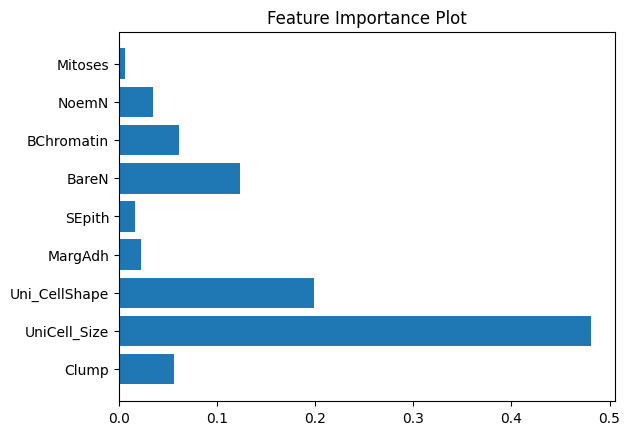

In [16]:
bm = RandomForestClassifier(random_state=26,max_features=6,n_estimators=25)

bm.fit(X,y)
# plt.figure(figsize=(35, 15))


df_imp = pd.DataFrame({'feature':X.columns,'importance':bm.feature_importances_})
plt.barh(df_imp['feature'],df_imp['importance'])
plt.title('Feature Importance Plot')
plt.show()